> ## ⚠️ Superseded — results below are known to be invalid (2026-08-04)
>
> This notebook is retained as the **rough draft** of the VRP research. Two adversarial audits on 2026-07-07 (`docs/audits/`) found defects that invalidate its conclusions:
>
> - **Walk-forward off-by-one (V-C1).** `forecast()` is called *before* the day-*t* observation is appended, so the ARMA forecast is scored as a 2-step forecast against naive's 1-step. Verified by re-execution 2026-07-24: with the alignment corrected, ARMA RMSE is 0.0318 vs naive 0.0327 (Diebold-Mariano p=0.30). **The headline finding "naive persistence beats ARMA" is an artifact of this bug**; the corrected result is that the two are statistically indistinguishable.
> - **Horizon mismatch (V-C2).** VRP here subtracts a *1-day-ahead* GARCH vol from *30-calendar-day* implied vol. Under vol mean reversion these differ even with zero risk premium, so the level statistics (82% of days positive, mean ~3 vol points) conflate premium with a term-structure artifact.
> - **"Cumulative VRP captured" is not P&L (V-C3).** It sums spread *levels*, which correspond to no position in any instrument, and the GARCH leg is known at decision time — inflating the reported hit rates.
>
> **Superseded by** `research/vrp_tail_v2.ipynb` (spec: `docs/specs/vrp-tail-v2.md`), which fixes the horizon match, defines the payoff as a synthetic variance-swap settlement, and reframes the question around tail reduction.
>
> Nothing below has been re-run. Read it as a record of the first attempt, not as findings.

# VRP-ARMA Signal

Spec: `docs/specs/vrp-arma-signal.md`

## 1. Imports & config

In [1]:
import os
import warnings
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
from scipy import stats
from scipy.stats import gaussian_kde
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tools.sm_exceptions import ConvergenceWarning, ValueWarning
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model

warnings.simplefilter('ignore', ValueWarning)
warnings.simplefilter('ignore', ConvergenceWarning)
warnings.simplefilter('ignore', FutureWarning)

In [2]:
DARK_BG    = '#111111'
DARK_PANEL = '#1a1a1a'
WHITE      = 'white'

def dark_ax(ax):
    ax.set_facecolor(DARK_PANEL)
    ax.tick_params(colors=WHITE)
    ax.xaxis.label.set_color(WHITE)
    ax.yaxis.label.set_color(WHITE)
    ax.title.set_color(WHITE)
    for spine in ax.spines.values():
        spine.set_visible(False)

def plot_vrp_kde(ax, data, title, pos_label='Positive', neg_label='Negative',
                 xlabel='VRP (annualized vol points)'):
    """KDE of VRP with ±95% CVaR tails and zero-crossing split."""
    data = np.asarray(data)
    hit    = (data > 0).mean()
    losses = data[data < 0]
    wins   = data[data > 0]
    cl = losses[losses <= np.percentile(losses, 5)].mean() if len(losses) else np.nan
    cw = wins[wins   >= np.percentile(wins,  95)].mean() if len(wins)   else np.nan

    x    = np.linspace(data.min(), data.max(), 500)
    y    = gaussian_kde(data, bw_method=0.15)(x)
    peak = y.max()

    ax.plot(x, y, color=WHITE, lw=1.5)
    ax.fill_between(x, y, where=(x >= 0), alpha=0.3, color='#4ade80',
                    label=f'{pos_label} ({hit:.1%})')
    ax.fill_between(x, y, where=(x <  0), alpha=0.3, color='#f87171',
                    label=f'{neg_label} ({1-hit:.1%})')
    ax.axvline(0,  color=WHITE,     lw=0.8, linestyle='--', alpha=0.5)
    ax.axvline(cl, color='#f87171', lw=1.2, linestyle=':',  alpha=0.9)
    ax.axvline(cw, color='#4ade80', lw=1.2, linestyle=':',  alpha=0.9)
    ax.annotate(f'CVaR {cl:.3f}', xy=(cl, 0), xytext=(cl - 0.01, peak * 0.25),
                color='#f87171', fontsize=8, ha='right')
    ax.annotate(f'CVaR {cw:.3f}', xy=(cw, 0), xytext=(cw + 0.01, peak * 0.25),
                color='#4ade80', fontsize=8, ha='left')
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Density')
    ax.legend(facecolor='#222222', labelcolor=WHITE, fontsize=9)
    return cl, cw, hit

## 2. Data pull (SPY + ^VIX) from 2016-2026

In [3]:
DATA_PATH = 'data/spy_vix_2016_2026.csv'

if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH, index_col='Date', parse_dates=True)
else:
    df = yf.download(['SPY', '^VIX'], start='2016-01-01', end='2026-01-01', interval='1d', auto_adjust=True)['Close']
    df.to_csv(DATA_PATH)

print(f'Shape: {df.shape}')
print(f'NaN count:')
print(df.isna().sum())
display(df.describe())
display(df.head())

Shape: (2514, 2)
NaN count:
SPY     0
^VIX    0
dtype: int64


,SPY,^VIX
count,2514.000000,2514.000000
mean,353.541732,18.497430
std,136.637324,7.331257
min,154.558807,9.140000
25%,240.381763,13.530000
50%,343.416809,16.690001
75%,429.732780,21.510000
max,688.499695,82.690002


,SPY,^VIX
Date,,
2016-01-04,169.908188,20.700001
2016-01-05,170.195557,19.340000
2016-01-06,168.048645,20.590000
2016-01-07,164.016907,24.990000
2016-01-08,162.216507,27.010000


## 3. Feature engineering + train/test split

`log_return` (daily SPY log return), `rolling_vol` (21-day realized vol, annualized), `vix_decimal` (VIX ÷ 100, matching vol units). Train is 2016–2021, test is 2022–2026. The 2022 cutoff is a natural structural break — the Fed rate hike cycle began, volatility regime shifted, and it gives a clean OOS period with meaningfully different market conditions than train.

In [4]:
df['log_return']  = np.log(df['SPY'] / df['SPY'].shift(1))
df['rolling_vol'] = df['log_return'].rolling(21).std() * np.sqrt(252)
df['vix_decimal'] = df['^VIX'] / 100
df.dropna(inplace=True)

TRAIN_END = '2022-01-01'
train = df[df.index < TRAIN_END]
test  = df[df.index >= TRAIN_END]

print(f'Train: {train.shape[0]} rows  ({train.index[0].date()} → {train.index[-1].date()})')
print(f'Test:  {test.shape[0]} rows  ({test.index[0].date()} → {test.index[-1].date()})')
display(df.describe())
display(df.head())

Train: 1490 rows  (2016-02-03 → 2021-12-31)
Test:  1003 rows  (2022-01-03 → 2025-12-31)


,SPY,^VIX,log_return,rolling_vol,vix_decimal
count,2493.000000,2493.000000,2493.000000,2493.000000,2493.000000
mean,355.155166,18.455652,0.000579,0.149391,0.184557
std,136.070624,7.344363,0.011336,0.102902,0.073444
min,154.558807,9.140000,-0.115886,0.034157,0.091400
25%,241.070923,13.490000,-0.003563,0.088529,0.134900
50%,346.465637,16.639999,0.000731,0.122352,0.166400
75%,430.541199,21.400000,0.005925,0.185307,0.214000
max,688.499695,82.690002,0.099863,0.936682,0.826900


,SPY,^VIX,log_return,rolling_vol,vix_decimal
Date,,,,,
2016-02-03,161.692520,21.650000,0.005977,0.233276,0.2165
2016-02-04,161.946091,21.840000,0.001567,0.233249,0.2184
2016-02-05,158.860992,23.379999,-0.019234,0.237951,0.2338
2016-02-08,156.722534,26.000000,-0.013553,0.228384,0.2600
2016-02-09,156.731003,26.540001,0.000054,0.226177,0.2654


## 4. EDA

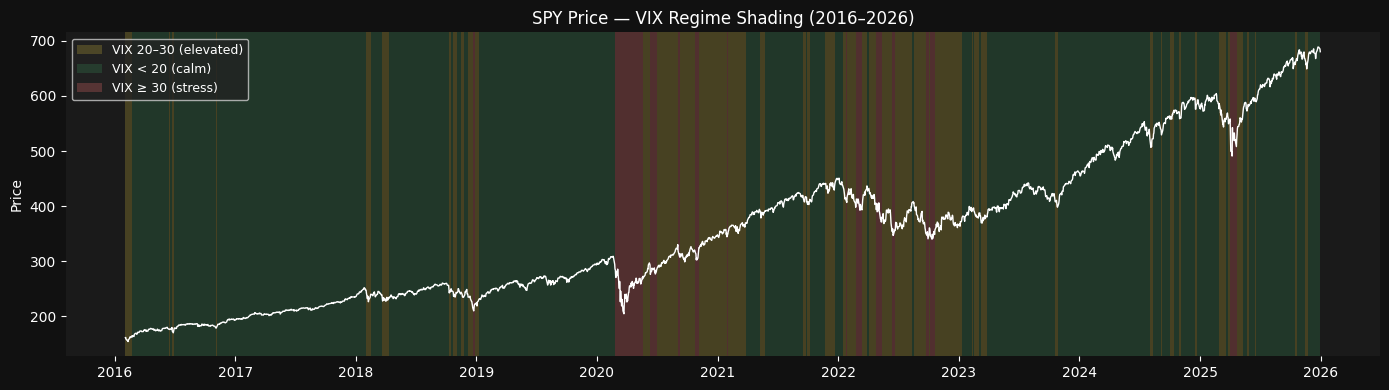

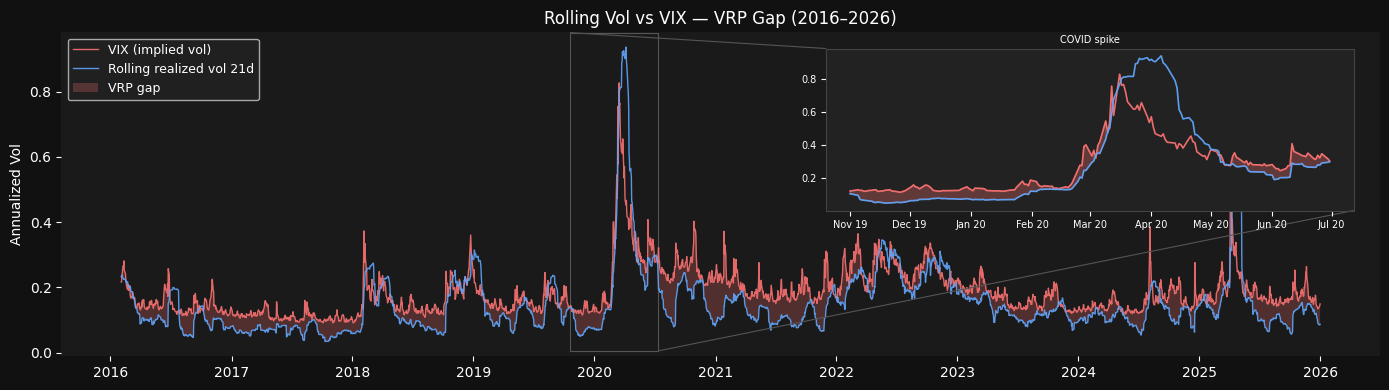

In [5]:
# ── SPY price with VIX regime shading ─────────────────────────────────────────
vix_smooth = df['^VIX'].rolling(5, center=True, min_periods=1).mean()
vix_regime = pd.cut(vix_smooth, bins=[-np.inf, 20, 30, np.inf],
                    labels=['calm', 'elevated', 'stress'])
regime_style = {
    'calm':     ('#4ade80', 0.15, 'VIX < 20 (calm)'),
    'elevated': ('#fde047', 0.20, 'VIX 20–30 (elevated)'),
    'stress':   ('#f87171', 0.25, 'VIX ≥ 30 (stress)'),
}

fig, ax = plt.subplots(figsize=(14, 4))
fig.patch.set_facecolor(DARK_BG)
dark_ax(ax)
ax.plot(df.index, df['SPY'], color=WHITE, lw=1, zorder=2)

labeled = set()
current_label, start_idx = vix_regime.iloc[0], vix_regime.index[0]
for date, label in vix_regime.items():
    if label != current_label:
        color, alpha, legend = regime_style[current_label]
        ax.axvspan(start_idx, date, color=color, alpha=alpha, lw=0, zorder=1,
                   label=legend if current_label not in labeled else None)
        labeled.add(current_label)
        current_label, start_idx = label, date
color, alpha, legend = regime_style[current_label]
ax.axvspan(start_idx, vix_regime.index[-1], color=color, alpha=alpha, lw=0, zorder=1,
           label=legend if current_label not in labeled else None)
ax.set_title('SPY Price — VIX Regime Shading (2016–2026)')
ax.set_ylabel('Price')
ax.legend(loc='upper left', facecolor='#222222', labelcolor=WHITE, fontsize=9)
plt.tight_layout()
plt.show()

# ── Rolling vol vs VIX — first look at the VRP gap ───────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
fig.patch.set_facecolor(DARK_BG)
dark_ax(ax)
ax.plot(df.index, df['vix_decimal'], color='#f87171', lw=1, label='VIX (implied vol)', alpha=0.9)
ax.plot(df.index, df['rolling_vol'], color='#60a5fa', lw=1, label='Rolling realized vol 21d', alpha=0.9)
ax.fill_between(df.index, df['rolling_vol'], df['vix_decimal'],
                where=(df['vix_decimal'] > df['rolling_vol']),
                alpha=0.25, color='#f87171', label='VRP gap', lw=0)
ax.set_title('Rolling Vol vs VIX — VRP Gap (2016–2026)')
ax.set_ylabel('Annualized Vol')
ax.legend(loc='upper left', facecolor='#222222', labelcolor=WHITE, fontsize=9)

axins = ax.inset_axes([0.58, 0.45, 0.40, 0.50])
axins.set_facecolor('#222222')
axins.tick_params(colors=WHITE, labelsize=7)
for spine in axins.spines.values():
    spine.set_color('#444444')
z = df['2019-11-01':'2020-06-30']
axins.plot(z.index, z['vix_decimal'], color='#f87171', lw=1.2, alpha=0.95)
axins.plot(z.index, z['rolling_vol'], color='#60a5fa', lw=1.2, alpha=0.95)
axins.fill_between(z.index, z['rolling_vol'], z['vix_decimal'],
                   where=(z['vix_decimal'] > z['rolling_vol']), alpha=0.3, color='#f87171')
axins.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %y'))
axins.set_title('COVID spike', color=WHITE, fontsize=7, pad=4)
mark_inset(ax, axins, loc1=2, loc2=4, fc='none', ec='#555555', lw=0.8)
plt.tight_layout()
plt.show()

The data spans all three VIX regimes (calm, elevated, and stress) confirming there is no regime bias in the sample. The VRP edge we measure is not an artifact of a single low-vol or high-vol period.

The bottom graph suggests VIX structurally exceeds realized vol. However, this is a preliminary look using rolling vol as a noisy proxy — it spikes with VIX but decays slowly, lagging actual market conditions. Ideally we'd compute realized vol from high-frequency intraday data, but that requires a paid data source. GARCH is our next best option, but we need to validate it first.

## 5. GARCH validation

GARCH models volatility as a function of past squared returns — it's only appropriate if returns exhibit volatility clustering (large moves tend to follow large moves). We check this by looking at the ACF/PACF of log returns vs squared log returns. If returns themselves show no autocorrelation but squared returns do, that confirms clustering and justifies GARCH.

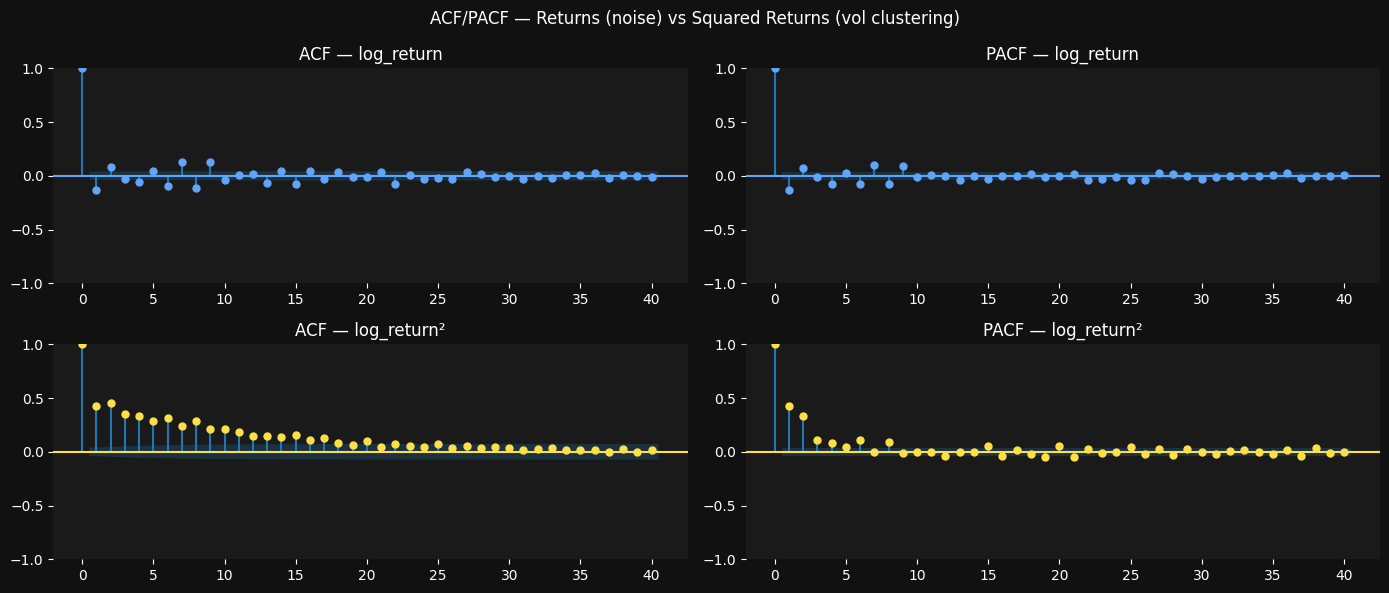

In [6]:
r  = df['log_return'].dropna()
r2 = r ** 2

# ── ACF/PACF — returns vs squared returns ─────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 6))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('ACF/PACF — Returns (noise) vs Squared Returns (vol clustering)', color=WHITE, fontsize=12)
for ax in axes.flat:
    dark_ax(ax)

plot_acf( r,  ax=axes[0, 0], lags=40, color='#60a5fa', title='ACF — log_return')
plot_pacf(r,  ax=axes[0, 1], lags=40, color='#60a5fa', title='PACF — log_return')
plot_acf( r2, ax=axes[1, 0], lags=40, color='#fde047', title='ACF — log_return²')
plot_pacf(r2, ax=axes[1, 1], lags=40, color='#fde047', title='PACF — log_return²')
for ax in axes.flat:
    ax.title.set_color(WHITE)

plt.tight_layout()
plt.show()

Squared returns show significant autocorrelation while raw returns do not — vol clustering confirmed, GARCH is appropriate. Now we need to choose an error distribution. The return distribution below will tell us whether the normal assumption holds or if we need heavier tails.

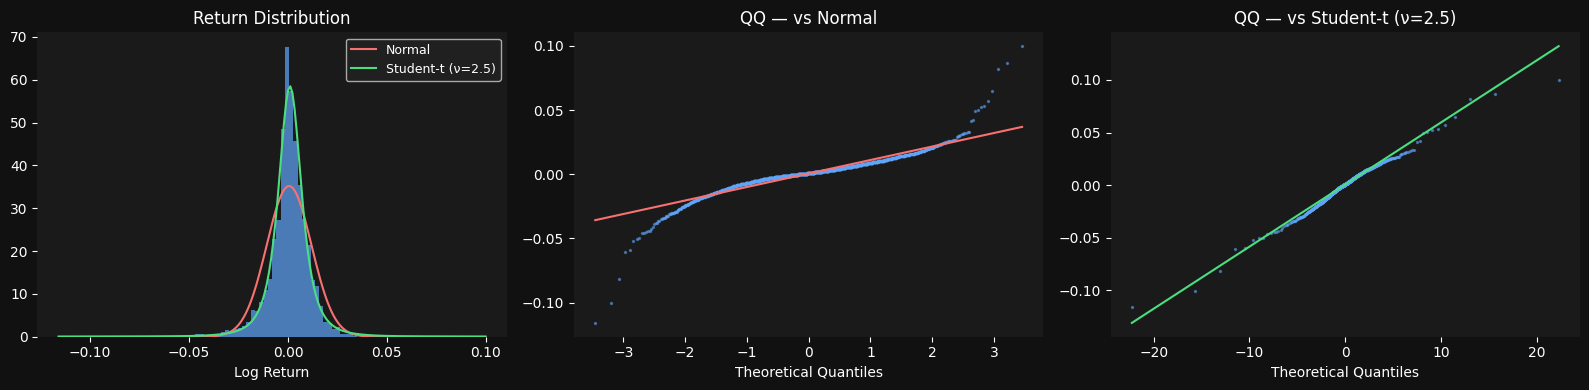

In [7]:
df_t, loc_t, scale_t = stats.t.fit(r)

# ── Return distribution + QQ ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.patch.set_facecolor(DARK_BG)
for ax in axes:
    dark_ax(ax)

axes[0].hist(r, bins=100, color='#60a5fa', alpha=0.7, density=True)
x = np.linspace(r.min(), r.max(), 200)
axes[0].plot(x, stats.norm.pdf(x, r.mean(), r.std()), color='#f87171', lw=1.5, label='Normal')
axes[0].plot(x, stats.t.pdf(x, df_t, loc_t, scale_t), color='#4ade80', lw=1.5, label=f'Student-t (ν={df_t:.1f})')
axes[0].set_title('Return Distribution')
axes[0].set_xlabel('Log Return')
axes[0].legend(facecolor='#222222', labelcolor=WHITE, fontsize=9)

(osm, osr), (slope, intercept, _) = stats.probplot(r, dist='norm')
axes[1].scatter(osm, osr, color='#60a5fa', s=2, alpha=0.5)
axes[1].plot(osm, slope * np.array(osm) + intercept, color='#f87171', lw=1.5)
axes[1].set_title('QQ — vs Normal')
axes[1].set_xlabel('Theoretical Quantiles')

(osm_t, osr_t), (slope_t, intercept_t, _) = stats.probplot(r, dist='t', sparams=(df_t,))
axes[2].scatter(osm_t, osr_t, color='#60a5fa', s=2, alpha=0.5)
axes[2].plot(osm_t, slope_t * np.array(osm_t) + intercept_t, color='#4ade80', lw=1.5)
axes[2].set_title(f'QQ — vs Student-t (ν={df_t:.1f})')
axes[2].set_xlabel('Theoretical Quantiles')

plt.tight_layout()
plt.show()

Returns have clear fat tails — the normal distribution underestimates extreme moves while Student-t fits much better. We'll let AIC/BIC confirm this formally by fitting both distributions and comparing.

In [8]:
model_n = arch_model(train['log_return'] * 100, vol='GARCH', p=1, q=1, mean='Zero', dist='normal')
res_n = model_n.fit(disp='off')

model_t = arch_model(train['log_return'] * 100, vol='GARCH', p=1, q=1, mean='Zero', dist='t')
res_t = model_t.fit(disp='off')

params_n = res_n.params
params_t = res_t.params

lb_n = acorr_ljungbox(res_n.std_resid, lags=[10], return_df=True)
lb_t = acorr_ljungbox(res_t.std_resid, lags=[10], return_df=True)

print('=== Normal GARCH(1,1) ===')
print(f"omega:      {params_n['omega']:.6f}")
print(f"alpha:      {params_n['alpha[1]']:.4f}")
print(f"beta:       {params_n['beta[1]']:.4f}")
print(f"alpha+beta: {params_n['alpha[1]'] + params_n['beta[1]']:.4f}")
print(f"AIC: {res_n.aic:.2f}  BIC: {res_n.bic:.2f}")
print(f"Ljung-Box p (lag 10): {lb_n['lb_pvalue'].values[0]:.4f}")

print('\n=== Student-t GARCH(1,1) ===')
print(f"omega:      {params_t['omega']:.6f}")
print(f"alpha:      {params_t['alpha[1]']:.4f}")
print(f"beta:       {params_t['beta[1]']:.4f}")
print(f"alpha+beta: {params_t['alpha[1]'] + params_t['beta[1]']:.4f}")
print(f"AIC: {res_t.aic:.2f}  BIC: {res_t.bic:.2f}")
print(f"Ljung-Box p (lag 10): {lb_t['lb_pvalue'].values[0]:.4f}")

garch_vol_train = (res_t.conditional_volatility / 100) * np.sqrt(252)

=== Normal GARCH(1,1) ===
omega:      0.047850
alpha:      0.2283
beta:       0.7282
alpha+beta: 0.9566
AIC: 3571.10  BIC: 3587.02
Ljung-Box p (lag 10): 0.6669

=== Student-t GARCH(1,1) ===
omega:      0.027733
alpha:      0.2166
beta:       0.7763
alpha+beta: 0.9928
AIC: 3435.36  BIC: 3456.59
Ljung-Box p (lag 10): 0.7521


Student-t wins on AIC/BIC by a wide margin (AIC: 3435 vs 3571 for Normal). Ljung-Box residuals are white noise — no remaining autocorrelation in the standardized residuals. GARCH(1,1) Student-t is validated. We now recurse the fitted model into the OOS period with fixed train parameters and compare it against rolling vol to confirm it's the better realized vol proxy.

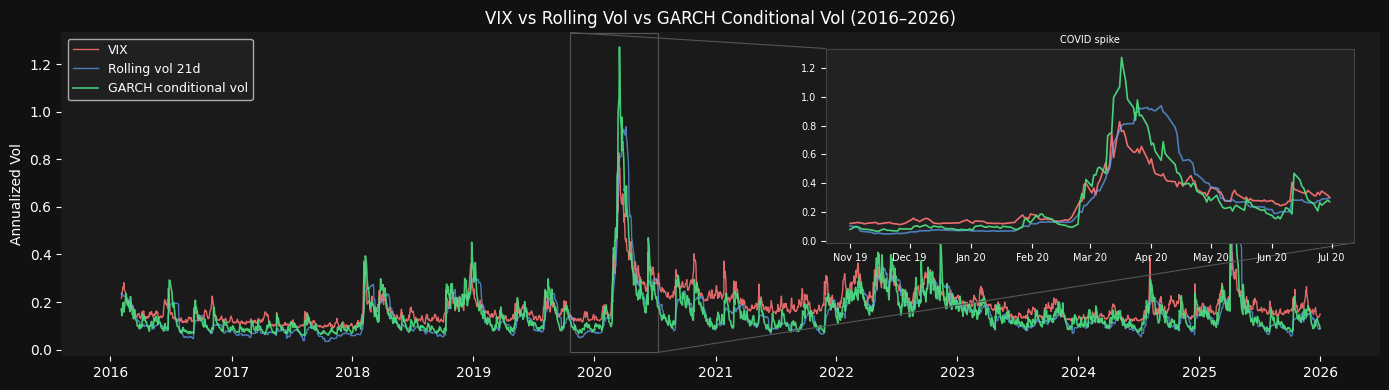

In [9]:
# recurse GARCH into OOS with fixed train params
omega = params_t['omega']
alpha = params_t['alpha[1]']
beta  = params_t['beta[1]']

last_var   = res_t.conditional_volatility.iloc[-1] ** 2
last_resid = (train['log_return'].iloc[-1] * 100) ** 2

test_returns = (test['log_return'] * 100).values
cond_var = np.zeros(len(test_returns))
for i in range(len(test_returns)):
    cond_var[i] = omega + alpha * last_resid + beta * last_var
    last_resid  = test_returns[i] ** 2
    last_var    = cond_var[i]

garch_vol_test = (np.sqrt(cond_var) / 100) * np.sqrt(252)
df['garch_cond_vol'] = pd.concat([
    pd.Series(garch_vol_train.values, index=train.index),
    pd.Series(garch_vol_test,         index=test.index)
])

z = df['2019-11-01':'2020-06-30']

fig, ax = plt.subplots(figsize=(14, 4))
fig.patch.set_facecolor(DARK_BG)
dark_ax(ax)

ax.plot(df.index, df['vix_decimal'],    color='#f87171', lw=1,   label='VIX', alpha=0.9)
ax.plot(df.index, df['rolling_vol'],    color='#60a5fa', lw=1,   label='Rolling vol 21d', alpha=0.7)
ax.plot(df.index, df['garch_cond_vol'], color='#4ade80', lw=1.2, label='GARCH conditional vol', alpha=0.9)
ax.set_title('VIX vs Rolling Vol vs GARCH Conditional Vol (2016–2026)')
ax.set_ylabel('Annualized Vol')
ax.legend(loc='upper left', facecolor='#222222', labelcolor=WHITE, fontsize=9)

axins = ax.inset_axes([0.58, 0.35, 0.40, 0.60])
axins.set_facecolor('#222222')
axins.tick_params(colors=WHITE, labelsize=7)
for spine in axins.spines.values():
    spine.set_color('#444444')
axins.plot(z.index, z['vix_decimal'],    color='#f87171', lw=1.2, alpha=0.95)
axins.plot(z.index, z['rolling_vol'],    color='#60a5fa', lw=1.2, alpha=0.7)
axins.plot(z.index, z['garch_cond_vol'], color='#4ade80', lw=1.2, alpha=0.95)
axins.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %y'))
axins.set_title('COVID spike', color=WHITE, fontsize=7, pad=4)
mark_inset(ax, axins, loc1=2, loc2=4, fc='none', ec='#555555', lw=0.8)

plt.tight_layout()
plt.show()

Rolling vol (blue) lags: after a spike it stays elevated for the full 21-day window before decaying. GARCH (green) responds immediately to each day's squared return and decays exponentially once conditions normalize. During the COVID spike GARCH momentarily overshoots VIX because GARCH is backward-looking (it saw actual 10–12% daily moves) while VIX is forward-looking options-implied vol — this is expected behavior. In calm periods GARCH sits below VIX, which is exactly the structural gap we're going to measure as VRP. Garch is the better proxy for realized vol and is what will be used going forward.

*Note: While we haven't emperically proven GARCH is better than rolling vol as a proxy, the visualizations and theory strongly support it. Furthermore, the argument is somewhat moot — in practice, both would be replaced by intraday-derived realized vol. GARCH is the best we can do with the data we have available to us.*

## 6. VRP construction

VRP > 0 (implied overpriced):  82.1% of days
VRP < 0 (implied underpriced): 17.9% of days
Unconditional mean VRP:        0.0290
CVaR 95% (win tail):           0.1352
CVaR 95% (loss tail):          -0.3089


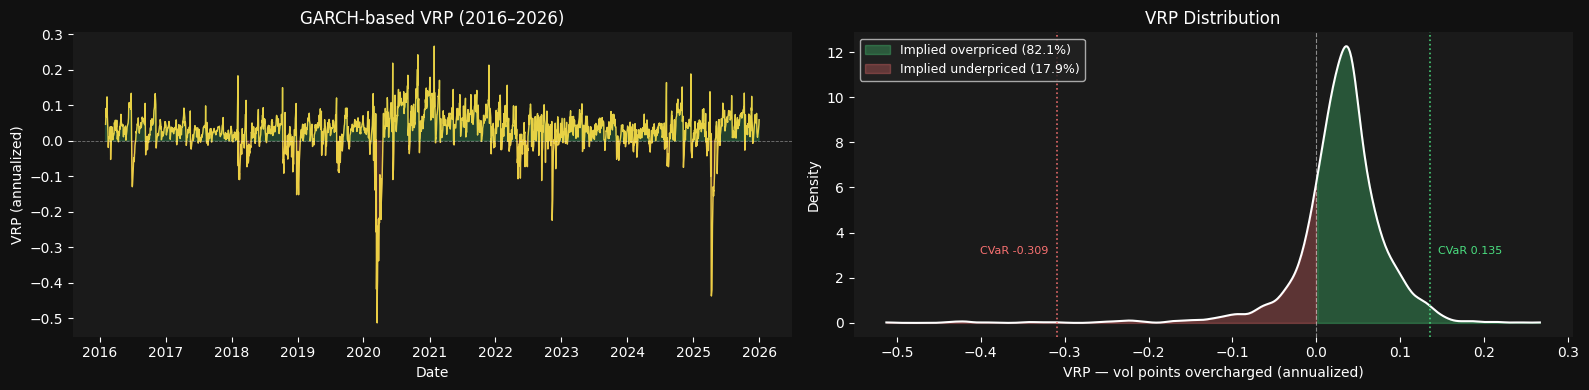

In [10]:
df['vrp'] = df['vix_decimal'] - df['garch_cond_vol']
vrp = df['vrp'].dropna()

hit_rate = (vrp > 0).mean()
print(f"VRP > 0 (implied overpriced):  {hit_rate:.1%} of days")
print(f"VRP < 0 (implied underpriced): {1-hit_rate:.1%} of days")
print(f"Unconditional mean VRP:        {vrp.mean():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
fig.patch.set_facecolor(DARK_BG)
for ax in axes:
    dark_ax(ax)

# ── GARCH VRP time series ──────────────────────────────────────────────────────
axes[0].plot(df.index, df['vrp'], color='#fde047', lw=1, alpha=0.9)
axes[0].axhline(0, color=WHITE, lw=0.6, linestyle='--', alpha=0.4)
axes[0].fill_between(df.index, 0, df['vrp'], where=(df['vrp'] > 0), alpha=0.2, color='#4ade80')
axes[0].fill_between(df.index, 0, df['vrp'], where=(df['vrp'] < 0), alpha=0.2, color='#f87171')
axes[0].set_title('GARCH-based VRP (2016–2026)')
axes[0].set_ylabel('VRP (annualized)')
axes[0].set_xlabel('Date')

# ── KDE distribution with CVaR tails ───────────────────────────────────────────
cl, cw, _ = plot_vrp_kde(
    axes[1], vrp.values, 'VRP Distribution',
    pos_label='Implied overpriced', neg_label='Implied underpriced',
    xlabel='VRP — vol points overcharged (annualized)',
)
print(f"CVaR 95% (win tail):           {cw:.4f}")
print(f"CVaR 95% (loss tail):          {cl:.4f}")

plt.tight_layout()
plt.show()

The unconditional VRP edge is real: implied vol exceeds realized vol on roughly 82% of days, with a mean VRP around 0.03 (3 vol points of structural overpricing). The distribution is right-skewed — most days sit in positive VRP territory.

However, the loss tail is fat. The worst 5% of underpricing days average around −0.31 in CVaR terms — large negative VRP events that would represent significant losses for an always-in short-vol position. The win tail (CVaR ~0.14) is less extreme in absolute terms, meaning the loss outliers are more severe than the win outliers. If a predictive signal could identify in advance when VRP is likely to turn negative and stay negative, stepping out of the trade on those days would shave off the worst of the loss tail without sacrificing much of the structural edge.

Looking at the VRP time series on the left, it appears visually stationary and mean-reverting — a potential candidate for ARMA forecasting. We verify this formally in the next section.

## 7. Stationarity + autocorrelation

ARMA requires a stationary input series meaning the series must have a stable mean and variance over time. VRP = VIX − GARCH_vol is likely stationary because both components are mean-reverting (VIX reverts to long-run average; GARCH vol tracks current market conditions). We confirm this with an ADF test before fitting.

Beyond stationarity, we want to see the persistence structure of VRP itself. The ACF/PACF of VRP shows how correlated today's VRP is with yesterday's, two days ago, etc. Significant lags in the PACF indicate the AR order; significant lags in the ACF after accounting for AR terms indicate the MA order. Crucially, because we're using GARCH-based VRP (not rolling vol), the ACF won't be mechanically inflated at lags 1–21.

ADF statistic:  -7.1558
Critical values: 1%=-3.435  5%=-2.863  10%=-2.568
p-value:        0.0000  ✓ stationary


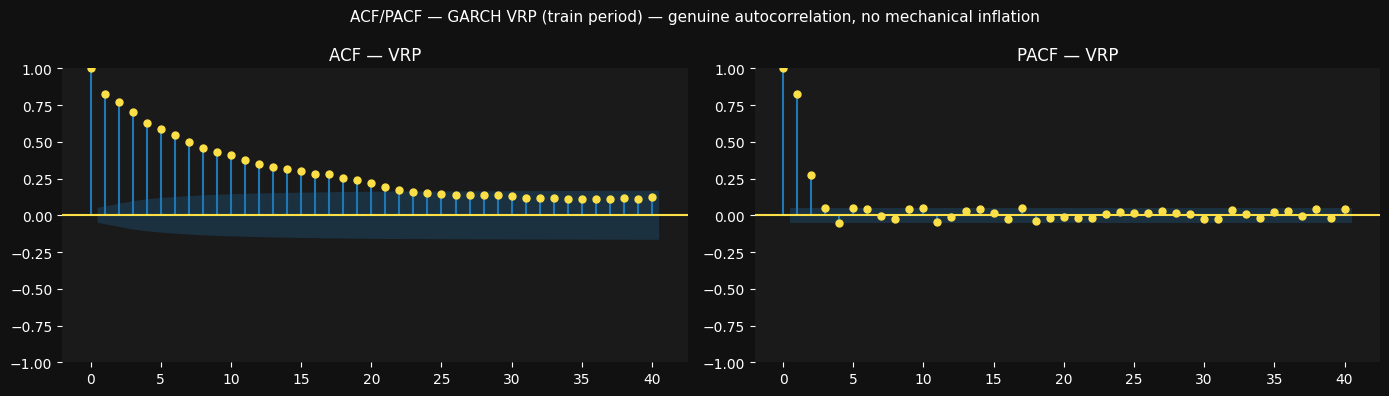

In [11]:
train_vrp = df.loc[df.index < TRAIN_END, 'vrp'].dropna()

adf_stat, adf_p, _, _, adf_crit, _ = adfuller(train_vrp)
print(f"ADF statistic:  {adf_stat:.4f}")
print(f"Critical values: 1%={adf_crit['1%']:.3f}  5%={adf_crit['5%']:.3f}  10%={adf_crit['10%']:.3f}")
print(f"p-value:        {adf_p:.4f}  {'✓ stationary' if adf_p < 0.05 else '✗ not stationary'}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('ACF/PACF — GARCH VRP (train period) — genuine autocorrelation, no mechanical inflation',
             color=WHITE, fontsize=11)
for ax in axes:
    dark_ax(ax)

plot_acf( train_vrp, ax=axes[0], lags=40, color='#fde047', title='ACF — VRP')
plot_pacf(train_vrp, ax=axes[1], lags=40, color='#fde047', title='PACF — VRP')
for ax in axes:
    ax.title.set_color(WHITE)

plt.tight_layout()
plt.show()

ADF confirms VRP is stationary on the train period. The PACF drops off sharply after lag 1–2, indicating an AR-dominated structure. The ACF decays slowly across many lags — this is not signaling 15+ MA terms, it is the geometric decay pattern of a high AR coefficient. An AR-driven series always produces a slow-decaying ACF. The grid search in the next section handles order selection precisely.

## 8. ARMA fit

With stationarity confirmed and autocorrelation structure visible, we fit an ARMA(p,q) model on the train period. ARMA treats VRP as a linear function of its own past values (AR terms) plus past forecast errors (MA terms), and generates 1-step-ahead forecasts. The goal is to predict tomorrow's VRP sign so we can enter the trade when positive VRP is expected and exit when reversion is forecast.

**Reading the ACF/PACF for order selection:** The textbook rule is "PACF tells you AR order, ACF tells you MA order" but this only holds cleanly for pure AR or pure MA processes. The VRP PACF cuts off sharply after lag 1–2, indicating an AR-dominated structure. The ACF decays slowly across many lags, which does not mean 15+ MA terms — it is the geometric decay pattern of a high AR coefficient. An AR-driven series always produces a slow-decaying ACF. We grid-search all combinations up to p=3, q=3 (excluding p=q=0, which is no model) and let AIC select the best.

**AIC vs BIC:** Both are scoring functions where lower is better. They start from how well the model fits, then add a penalty for each extra parameter to discourage overfitting. The difference is just how harsh the penalty is: AIC adds 2 per parameter regardless of sample size; BIC adds log(n) per parameter, which for our 1490-observation train set is about 7.3. So BIC penalizes complexity roughly 3× harder. In practice AIC tends to pick larger models and BIC picks simpler ones. We use AIC to drive selection since we care about forecast accuracy, and report BIC as a cross-check on whether the extra parameters are justified.

In [12]:
results = []
for p in range(0, 4):
    for q in range(0, 4):
        if p == 0 and q == 0:
            continue
        try:
            model = ARIMA(train_vrp, order=(p, 0, q)).fit()
            results.append({'p': p, 'q': q, 'aic': model.aic, 'bic': model.bic})
        except Exception:
            pass

grid = pd.DataFrame(results).sort_values('aic').reset_index(drop=True)
print("ARMA grid search — top 10 by AIC:")
print(grid.head(10).to_string(index=False))

p_best = int(grid.iloc[0]['p'])
q_best = int(grid.iloc[0]['q'])
print(f"\nSelected: ARMA({p_best}, {q_best})")

arma_fit = ARIMA(train_vrp, order=(p_best, 0, q_best)).fit()
print(arma_fit.summary())

ARMA grid search — top 10 by AIC:
 p  q          aic          bic
 3  3 -6036.706747 -5994.254496
 3  0 -6024.517542 -5997.984885
 1  2 -6024.458859 -5997.926202
 3  1 -6024.011287 -5992.172099
 2  1 -6023.388173 -5996.855516
 2  0 -6022.994385 -6001.768259
 1  3 -6022.461895 -5990.622706
 3  2 -6022.167212 -5985.021492
 2  2 -6021.390235 -5989.551047
 2  3 -6021.164963 -5984.019243

Selected: ARMA(3, 3)
                               SARIMAX Results                                
Dep. Variable:                    vrp   No. Observations:                 1490
Model:                 ARIMA(3, 0, 3)   Log Likelihood                3026.353
Date:                Thu, 23 Apr 2026   AIC                          -6036.707
Time:                        02:13:51   BIC                          -5994.254
Sample:                             0   HQIC                         -6020.886
                               - 1490                                         
Covariance Type:                  opg  

In [13]:
lb = acorr_ljungbox(arma_fit.resid, lags=[10, 20], return_df=True)
print("Ljung-Box residual test:")
print(lb.to_string())
print("\nResiduals are white noise if p-values > 0.05")

Ljung-Box residual test:
      lb_stat  lb_pvalue
10   3.870057   0.953019
20  14.948567   0.779343

Residuals are white noise if p-values > 0.05


Ljung-Box residuals are white noise (p > 0.05 at lags 10 and 20) — the ARMA model has captured the autocorrelation structure and there is no remaining predictable pattern in the residuals. The high kurtosis in the SARIMAX summary is expected: VRP inherits the fat tails of the underlying return distribution, and ARMA does not model that — it models the mean structure only. The model is ready for OOS forecasting.

## 9. OOS walk-forward forecasts

We evaluate forecast quality on the held-out 2022–2026 period. The walk-forward methodology is strict: at each day t, we forecast VRP at t+1 using only data available up to t. The ARMA parameters are fixed at their train-period values — no refitting on OOS data. This avoids look-ahead bias.

The naive baseline is the simplest possible forecast: predict tomorrow's VRP equals today's VRP. Beating naive on RMSE would confirm that ARMA extracts genuine signal beyond simple persistence.

In [14]:
oos_vrp = df.loc[df.index >= TRAIN_END, 'vrp'].dropna()

forecasts = []
current = arma_fit
for vrp_val in oos_vrp.iloc[:-1]:
    fc = current.forecast(steps=1)
    forecasts.append(float(fc.iloc[0]))
    current = current.append([vrp_val], refit=False)

forecast_index = oos_vrp.index[:-1]
actuals        = oos_vrp.iloc[1:].values
naive          = oos_vrp.iloc[:-1].values

rmse_arma  = np.sqrt(np.mean((np.array(forecasts) - actuals) ** 2))
rmse_naive = np.sqrt(np.mean((naive - actuals) ** 2))
mae_arma   = np.mean(np.abs(np.array(forecasts) - actuals))
mae_naive  = np.mean(np.abs(naive - actuals))

print(f"ARMA({p_best},{q_best}) RMSE: {rmse_arma:.5f}  |  Naive RMSE: {rmse_naive:.5f}")
print(f"ARMA({p_best},{q_best}) MAE:  {mae_arma:.5f}  |  Naive MAE:  {mae_naive:.5f}")

ARMA(3,3) RMSE: 0.03991  |  Naive RMSE: 0.03272
ARMA(3,3) MAE:  0.02586  |  Naive MAE:  0.02099


ARMA RMSE (0.03991) is worse than naive (0.03272) — the model does not improve point forecast accuracy. The gap is driven largely by the two major vol spikes in the OOS period (late 2022, early 2025): when VRP collapses suddenly, ARMA extrapolates persistence and gets caught off-guard just as naive does. This rules out magnitude-based position sizing.

This shifts the question to sign accuracy, which is independent of magnitude accuracy. Given that VRP is autocorrelated (as sections 7 and 8 established), the simplest possible binary signal is: be in the trade when today's VRP is positive, since positive VRP today is a strong predictor of positive VRP tomorrow. This is the naive binary rule which is grounded directly in the autocorrelation structure we measured.

ARMA-timed makes a more specific claim: by weighting the last 3 days of VRP and forecast errors, it can detect downward momentum early and forecast a zero-crossing before it happens — stepping out one day earlier than naive binary at transitions. Whether that lead-time advantage is real, or whether the added complexity hurts more than it helps out-of-sample, is what section 10 tests.

## 10. Backtest

We compare three strategies over the OOS period: **always-in** (short vol every day), **naive binary** (in when today's VRP > 0, out when today's VRP < 0), and **ARMA-timed** (in when the model forecasts positive VRP for tomorrow).

Always-in is the unconditional baseline — no signal, full exposure. Naive binary is the simplest possible signal: react to whether today's VRP is positive. Since VRP is positive ~82% of days, naive binary is in roughly 82% of the time and exits only after VRP has already crossed zero. ARMA-timed is the forward-looking version: the model weighs the last 3 days of VRP and forecast errors to predict tomorrow's value, and can detect downward momentum early enough to step out before the crossing happens.

Metrics: hit rate (fraction of in-trade days where actual VRP > 0), mean VRP captured per day, and std of VRP per day.

Strategy              days_in       hit_rate        mean_vrp        std_vrp
-------------------------------------------------------------------------------------
Always-in             days_in=1002  hit_rate=80.6%  mean_vrp=0.0256  std_vrp=0.0509
Naive binary          days_in= 808  hit_rate=92.3%  mean_vrp=0.0391  std_vrp=0.0328
ARMA(3,3) timed       days_in= 843  hit_rate=87.9%  mean_vrp=0.0354  std_vrp=0.0366


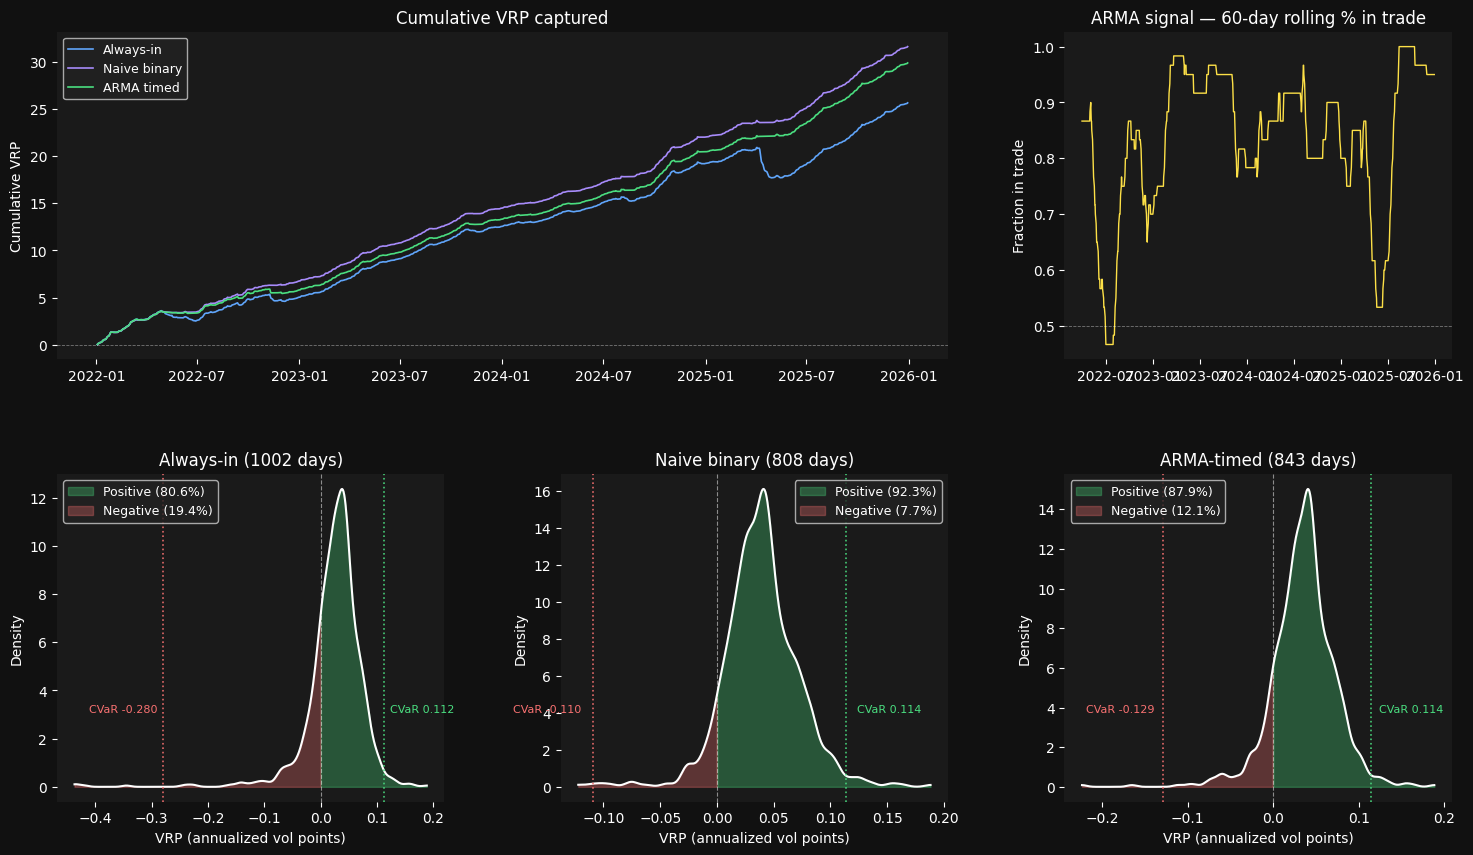

In [15]:
from matplotlib.gridspec import GridSpec

actual_next = pd.Series(actuals, index=forecast_index)
fc_series   = pd.Series(forecasts, index=forecast_index)

always_in = pd.Series(True, index=forecast_index)
naive_in  = pd.Series(oos_vrp.iloc[:-1].values > 0, index=forecast_index)
arma_in   = fc_series > 0

def backtest_stats(signal, actual_vrp, label):
    days_in  = signal.sum()
    vrp_in   = actual_vrp[signal]
    hit_rate = (vrp_in > 0).mean()
    mean_vrp = vrp_in.mean()
    std_vrp  = vrp_in.std()
    print(f"{label:20s}  days_in={days_in:4d}  hit_rate={hit_rate:.1%}  mean_vrp={mean_vrp:.4f}  std_vrp={std_vrp:.4f}")

print(f"{'Strategy':20s}  {'days_in':>7}  {'hit_rate':>13}  {'mean_vrp':>14}  {'std_vrp':>13}")
print("-" * 85)
backtest_stats(always_in, actual_next, 'Always-in')
backtest_stats(naive_in,  actual_next, 'Naive binary')
backtest_stats(arma_in,   actual_next, f'ARMA({p_best},{q_best}) timed')

fig = plt.figure(figsize=(18, 10))
fig.patch.set_facecolor(DARK_BG)
gs = GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.3)

ax_cum  = fig.add_subplot(gs[0, :2])
ax_roll = fig.add_subplot(gs[0, 2])
ax_d1   = fig.add_subplot(gs[1, 0])
ax_d2   = fig.add_subplot(gs[1, 1])
ax_d3   = fig.add_subplot(gs[1, 2])

for ax in [ax_cum, ax_roll, ax_d1, ax_d2, ax_d3]:
    dark_ax(ax)

# cumulative VRP — three strategies
always_cum = actual_next[always_in].cumsum()
naive_cum  = actual_next[naive_in].cumsum()
arma_cum   = actual_next[arma_in].cumsum()
ax_cum.plot(always_cum.index, always_cum.values, color='#60a5fa', lw=1.2, label='Always-in')
ax_cum.plot(naive_cum.index,  naive_cum.values,  color='#a78bfa', lw=1.2, label='Naive binary')
ax_cum.plot(arma_cum.index,   arma_cum.values,   color='#4ade80', lw=1.2, label='ARMA timed')
ax_cum.axhline(0, color=WHITE, lw=0.6, linestyle='--', alpha=0.4)
ax_cum.set_title('Cumulative VRP captured')
ax_cum.set_ylabel('Cumulative VRP')
ax_cum.legend(facecolor='#222222', labelcolor=WHITE, fontsize=9)

# 60-day rolling % in trade (ARMA only — always-in is 100%, naive binary is ~82%)
in_pct = arma_in.rolling(60).mean()
ax_roll.plot(in_pct.index, in_pct.values, color='#fde047', lw=1)
ax_roll.axhline(0.5, color=WHITE, lw=0.6, linestyle='--', alpha=0.4)
ax_roll.set_title('ARMA signal — 60-day rolling % in trade')
ax_roll.set_ylabel('Fraction in trade')

# strategy distributions
plot_vrp_kde(ax_d1, actual_next[always_in].values, f'Always-in ({always_in.sum()} days)')
plot_vrp_kde(ax_d2, actual_next[naive_in].values,  f'Naive binary ({naive_in.sum()} days)')
plot_vrp_kde(ax_d3, actual_next[arma_in].values,   f'ARMA-timed ({arma_in.sum()} days)')

plt.show()

The results are clear and run counter to the hypothesis. Naive binary dominates on every metric: 808 days in trade, 92.3% hit rate, mean VRP 0.0391, std 0.0328. ARMA-timed has 35 more days in trade (843 vs 808) yet a lower hit rate (87.9%) and higher std (0.0366) — meaning it generates more false positives, staying in on days naive binary correctly sits out. The lead-time advantage ARMA claimed did not materialize.

The cumulative curves (top-left) show the gap: naive binary (purple) pulls ahead of always-in consistently, while ARMA-timed (green) trails behind it throughout the OOS period. The distributions (bottom row) confirm it: naive binary's loss CVaR (−0.110) is far less severe than always-in (−0.280), and ARMA-timed sits between the two (−0.129). Simple persistence filtering removed more tail risk than ARMA's complexity did.

## 11. Key findings

### 1. The VRP edge is structural and regime-robust
VIX exceeds GARCH conditional vol on 80.6% of OOS days across a period that includes a rate hike cycle, an extended vol regime shift, and a sharp 2025 vol spike. The mean VRP is consistently positive and holds across all three VIX regimes — calm, elevated, and stress. This is not a calm-market artifact: an always-in short-vol position captures real, persistent structural overpricing in implied vol.

### 2. VRP autocorrelation is the mechanism behind any timing edge
ADF confirms stationarity. The ACF/PACF of train-period VRP shows clear short-lag persistence — positive VRP today is a strong predictor of positive VRP tomorrow. This is not noise: it reflects the same vol clustering that justifies GARCH. It is also the property that makes any binary timing rule work at all, and understanding it is what motivated the entire approach.

### 3. Simple persistence beats complex forecasting out-of-sample
The naive binary rule — in when today's VRP > 0, out when negative — achieves 92.3% hit rate in 808 days with mean VRP of 0.0391 and std of 0.0328. It outperforms ARMA-timed on every metric despite using a single observation and no model. This is a common and well-documented pattern in financial time series: models that fit training dynamics well frequently lose to simpler rules when the regime shifts. The 2022–2026 OOS period, with its structural rate and vol regime change, is exactly the kind of environment where overfitting hurts most.

### 4. ARMA failed in both dimensions — magnitude and direction
Walk-forward RMSE: ARMA(3,3) = 0.03991 vs naive persistence = 0.03272 — worse on magnitude. In the backtest, ARMA has 35 more days in trade than naive binary yet a lower hit rate — meaning it generates false positives, remaining in on days naive binary correctly exits. The model captured the autocorrelation structure of the training period precisely; it did not generalize to the OOS regime.

### 5. Tail risk is spike-concentrated, not systematic
The loss distribution is not a uniform spread of modestly bad days — it is dominated by two discrete events: the late 2022 rate hike shock and the early 2025 vol spike. During these, all strategies were caught off-guard and VRP collapsed sharply. The primary risk of a short-vol position is not day-to-day VRP variance but sudden regime transitions that no daily signal tested here can anticipate.

### 6. Strategy implication: simple persistence is the signal
The actionable result is the naive binary rule itself. It exploits the autocorrelation structure directly, achieves a 92.3% hit rate with 19% fewer days at risk than always-in, substantially trims the loss tail (CVaR −0.110 vs −0.280 always-in), and does so without model risk or overfitting. ARMA was the proposed mechanism to generate that edge — the data shows the edge was already in simple persistence, and ARMA added noise rather than signal.

---

## Outputs

- [Summary Analysis Report](https://htmlpreview.github.io/?https://github.com/bsinek/sentinel/blob/main/research/VRP-ARMA_Report.html)
- [Presentation Slide](https://htmlpreview.github.io/?https://github.com/bsinek/sentinel/blob/main/research/VRP-ARMA_Slide.html)